# MAKİNE ÖĞRENMESİ 501

## 1. K- MEANS ALGORİTMASI

### Kütüphaneler

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings ("ignore", category=DeprecationWarning)
warnings.filterwarnings ("ignore", category=FutureWarning)

### VERİ SETİ

In [3]:
df = pd.read_csv("./USArrests.csv")

In [4]:
df.head()

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [5]:
df = pd.read_csv("./USArrests.csv", index_col =0)

In [6]:
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [7]:
df.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


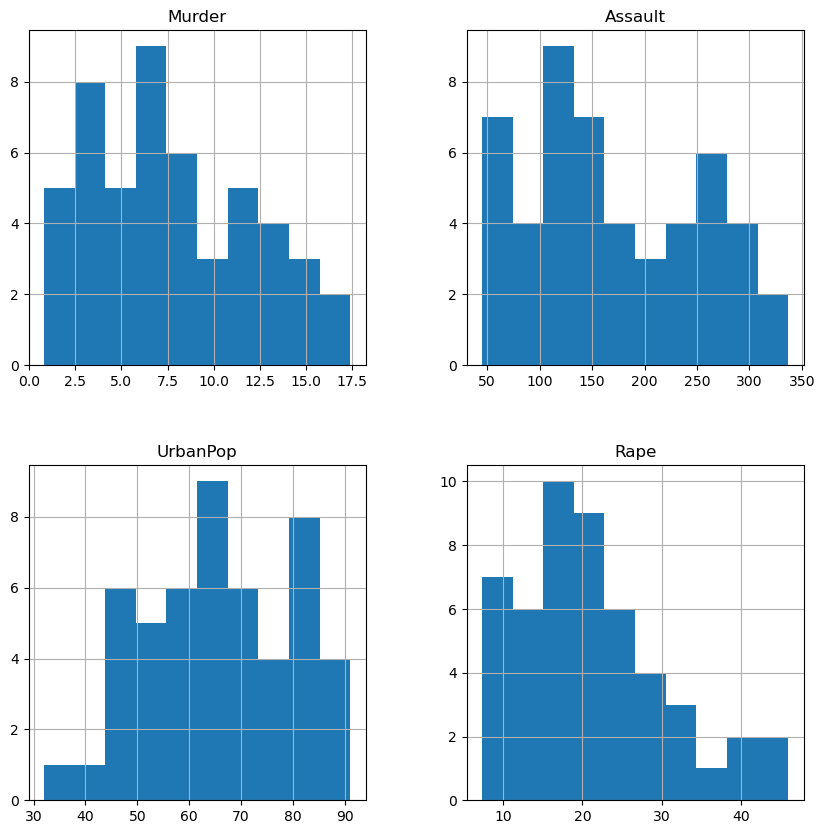

In [11]:
df.hist(figsize=(10,10));

In [12]:
kmeans = KMeans(n_clusters=4)

In [13]:
kmeans

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [14]:
k_fit = kmeans.fit(df)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [15]:
k_fit.n_clusters

4

In [18]:
k_fit.cluster_centers_

array([[  6.32857143, 139.71428571,  67.95238095,  19.16666667],
       [ 11.8       , 300.85714286,  68.71428571,  28.85714286],
       [  2.95      ,  62.7       ,  53.9       ,  11.51      ],
       [ 12.03333333, 239.25      ,  69.16666667,  28.5       ]])

In [19]:
k_fit.labels_

array([3, 3, 1, 0, 1, 3, 0, 3, 1, 3, 2, 0, 3, 0, 2, 0, 0, 3, 2, 1, 0, 3,
       2, 3, 0, 0, 0, 3, 2, 0, 1, 3, 1, 2, 0, 0, 0, 0, 0, 1, 2, 0, 3, 0,
       2, 0, 0, 2, 2, 0], dtype=int32)

#### kumelerin gorsellestirilmesi

In [20]:
k_means = KMeans(n_clusters = 2).fit(df)

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [21]:
kumeler = k_means.labels_

In [22]:
kumeler

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

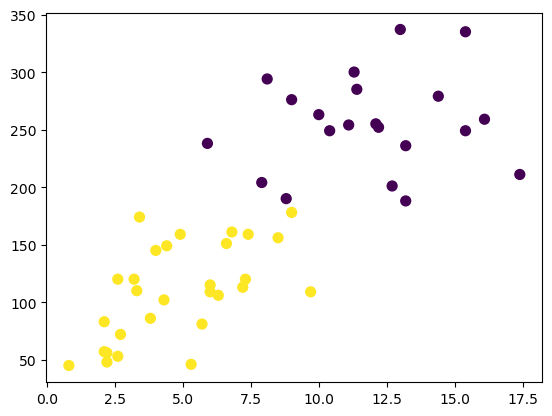

In [26]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=kumeler, s = 50, cmap="viridis");

In [27]:
merkezler = k_means.cluster_centers_

In [28]:
merkezler

array([[ 11.85714286, 255.        ,  67.61904762,  28.11428571],
       [  4.84137931, 109.75862069,  64.03448276,  16.24827586]])

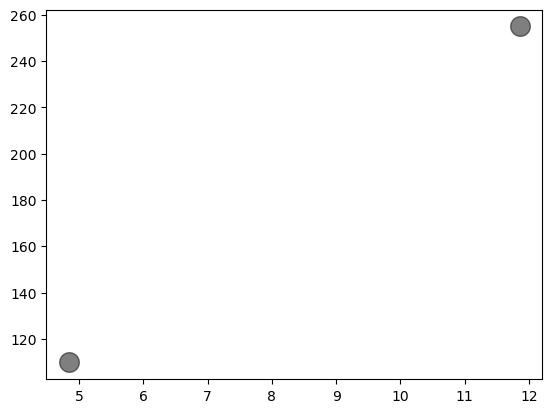

In [29]:
plt.scatter(merkezler [:,0], merkezler[:,1], c="black", s=200, alpha=0.5);

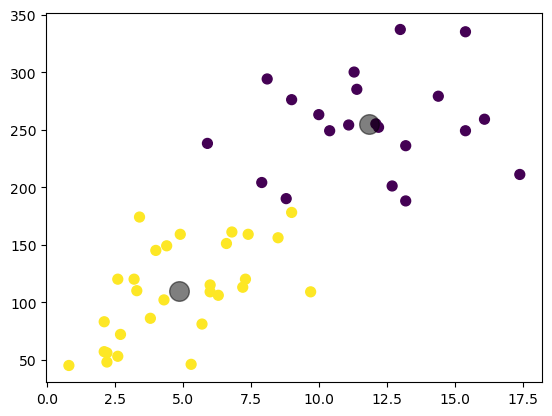

In [30]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=kumeler, s = 50, cmap="viridis")
plt.scatter(merkezler [:,0], merkezler[:,1], c="black", s=200, alpha=0.5)

## 1.1. K- MEANS ALGORİTMASI--OPTİMUM KÜME SAYISININ BELİRLENMESİ

### Elbow Yöntemi

In [31]:
df

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9
Georgia,17.4,211,60,25.8


In [34]:
ssd = []

K = range(1,30)

for k in K:
    kmeans = KMeans(n_clusters = k).fit(df)
    ssd.append(kmeans.inertia_)
    

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'Optimum Küme Sayısı İçin Elbow Yöntemi')

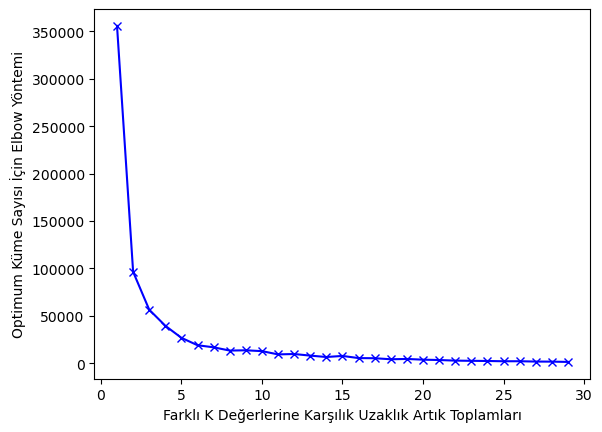

In [35]:
plt.plot(K, ssd, "bx-")
plt.xlabel("Farklı K Değerlerine Karşılık Uzaklık Artık Toplamları")
plt.ylabel("Optimum Küme Sayısı İçin Elbow Yöntemi")

In [36]:
!pip install yellowbrick

In [37]:
from yellowbrick.cluster import KElbowVisualizer

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

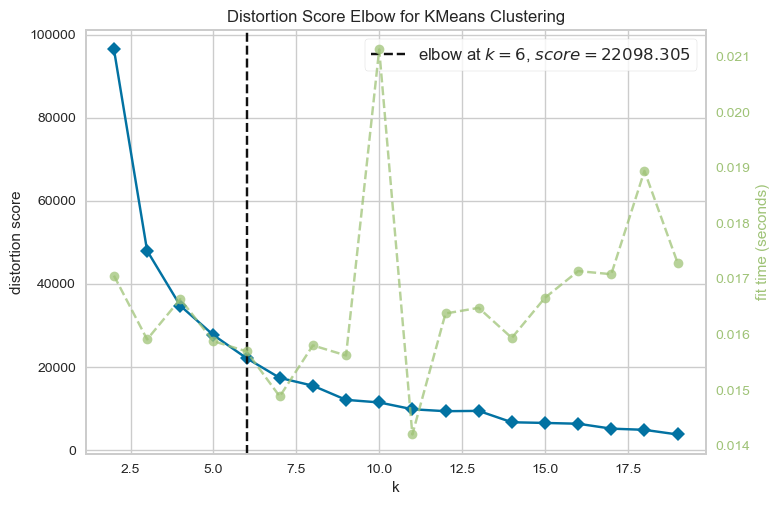

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [39]:
kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k = (2,20))
visu.fit(df)
visu.poof()

In [41]:
## final k-meansi (Elbow' a Göre)

In [48]:
kmeans = KMeans(n_clusters=4).fit(df)
kmeans

C:\Users\hkoca\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [43]:
kumeler = k_means.labels_

In [49]:
pd.DataFrame({"Eyaletler": df.index, "Kumeler": kumeler})

,Eyaletler,Kumeler
0,Alabama,2
1,Alaska,2
2,Arizona,1
3,Arkansas,2
4,California,1
5,Colorado,2
6,Connecticut,0
7,Delaware,2
8,Florida,1
9,Georgia,2


In [50]:
df["Kume_No"] = kumeler

In [51]:
df

,Murder,Assault,UrbanPop,Rape,Kume_No
Alabama,13.2,236,58,21.2,2
Alaska,10.0,263,48,44.5,2
Arizona,8.1,294,80,31.0,1
Arkansas,8.8,190,50,19.5,2
California,9.0,276,91,40.6,1
Colorado,7.9,204,78,38.7,2
Connecticut,3.3,110,77,11.1,0
Delaware,5.9,238,72,15.8,2
Florida,15.4,335,80,31.9,1
Georgia,17.4,211,60,25.8,2


## 2.HİYERARŞİK KÜMELEME YÖNTEMİ

In [52]:
from scipy.cluster.hierarchy import linkage

In [53]:
hc_complete = linkage(df, "complete")
hc_average = linkage(df, "average")

In [54]:
from scipy.cluster.hierarchy import dendrogram

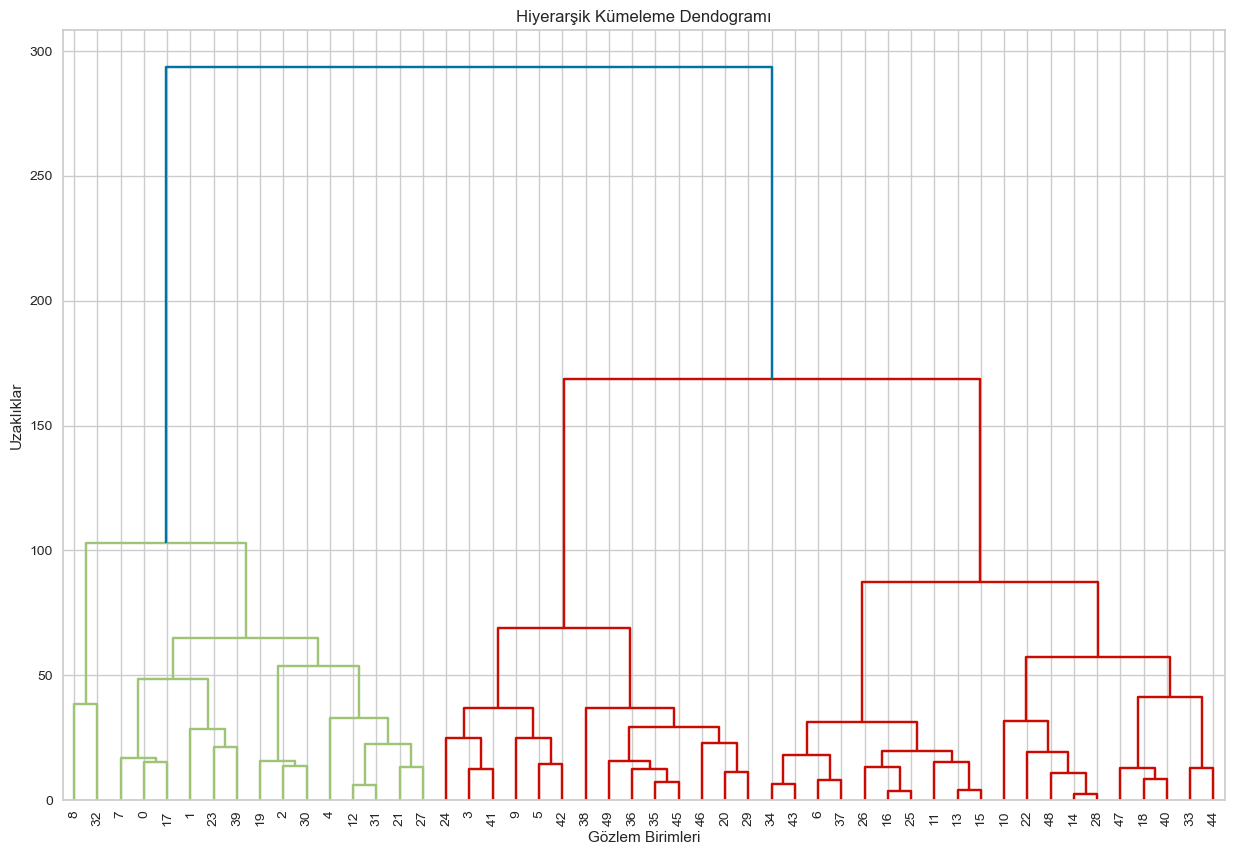

In [57]:
plt.figure(figsize = (15,10))
plt.title("Hiyerarşik Kümeleme Dendogramı")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_complete,
           leaf_font_size=10);

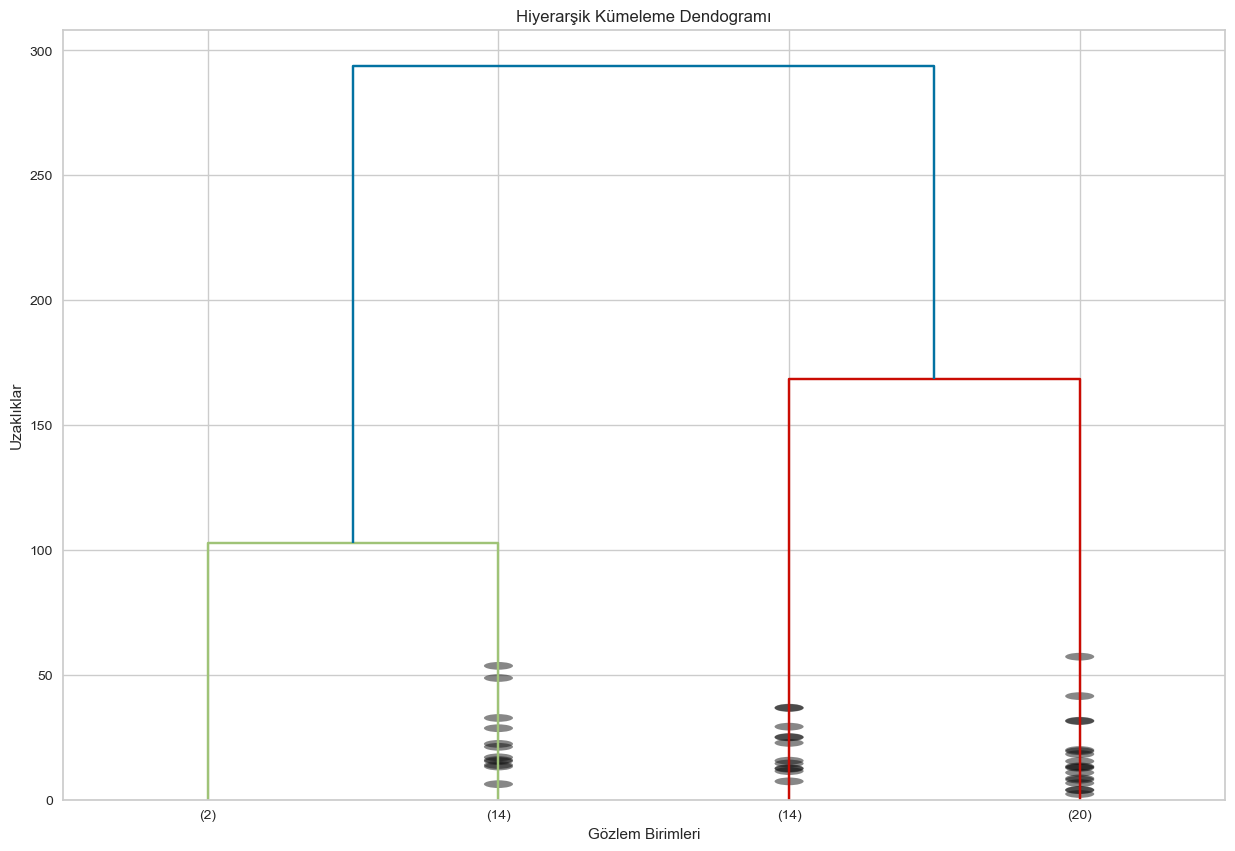

In [58]:
plt.figure(figsize = (15,10))
plt.title("Hiyerarşik Kümeleme Dendogramı")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_complete,
           truncate_mode="lastp",
           p = 4,
           show_contracted=True,
           leaf_font_size=10);

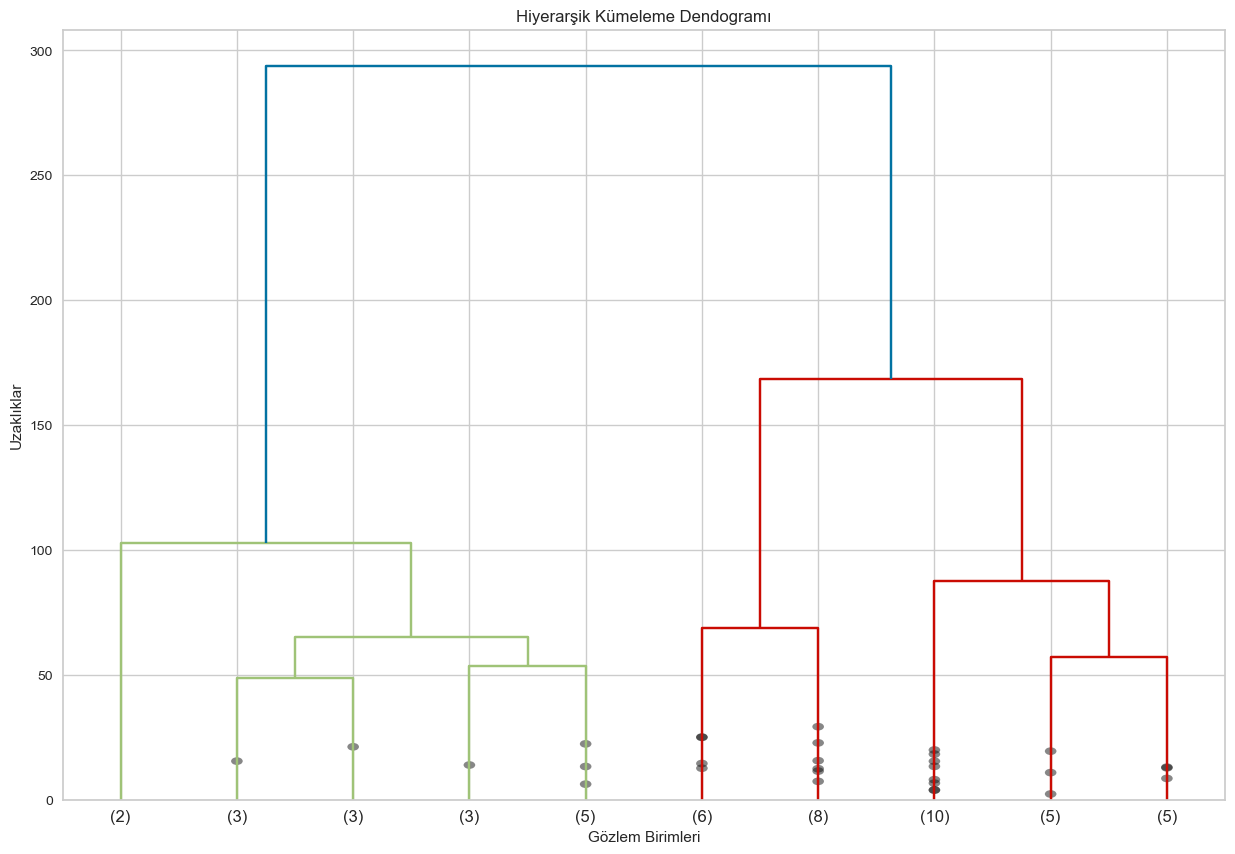

In [59]:
plt.figure(figsize = (15,10))
plt.title("Hiyerarşik Kümeleme Dendogramı")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_complete,
           truncate_mode="lastp",
           p = 10,
           show_contracted=True);

In [60]:
## diğer yöntem-average fonk lu olan.

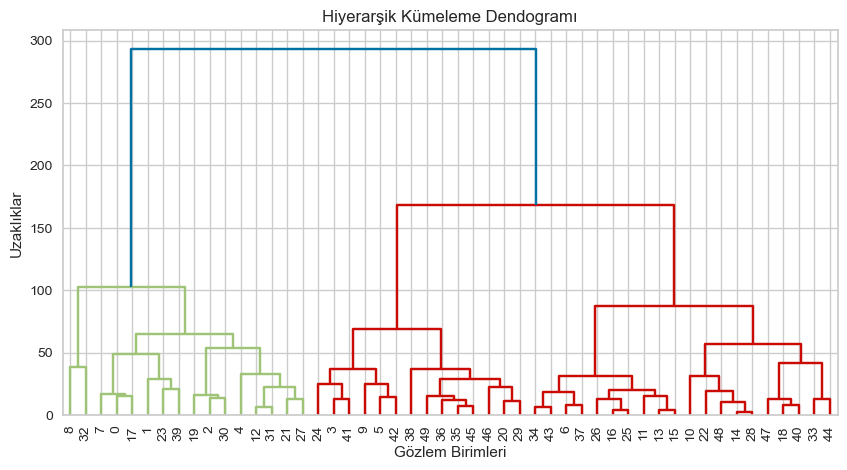

In [61]:
plt.figure(figsize = (10,5))
plt.title("Hiyerarşik Kümeleme Dendogramı")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_complete,
           leaf_font_size=10);

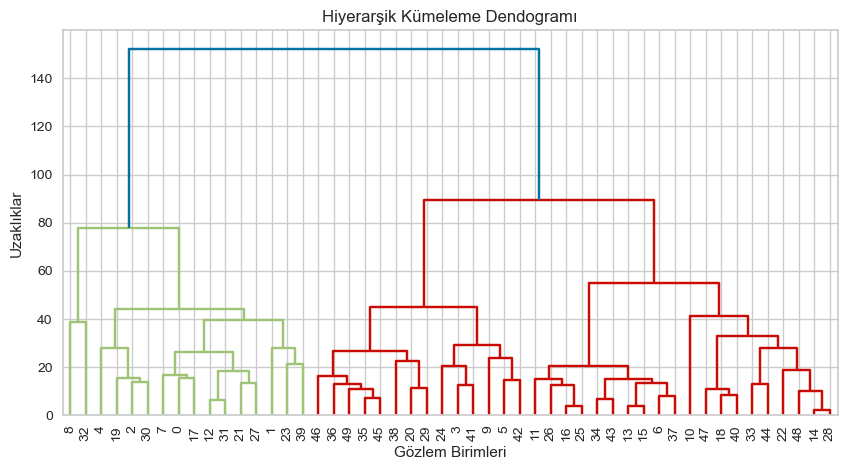

In [62]:
plt.figure(figsize = (10,5))
plt.title("Hiyerarşik Kümeleme Dendogramı")
plt.xlabel("Gözlem Birimleri")
plt.ylabel("Uzaklıklar")
dendrogram(hc_average,
           leaf_font_size=10);

## 3. TEMEL BİLEŞEN ANALİZİ

In [63]:
df = pd.read_csv("./Hitters.csv")
df.dropna(inplace = True)
df = df._get_numeric_data()
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0


In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
df = StandardScaler().fit_transform(df)

In [66]:
df[0:5, 0:5]

array([[-0.6029005 , -0.59567545, -0.5285512 , -1.2061115 , -0.52206292],
       [ 0.51254171,  0.49225957,  0.72996619,  0.44151497,  0.79405962],
       [ 0.62816682,  0.73648988,  0.95878753,  0.40228577,  1.02631654],
       [-0.56209164, -0.46245892, -0.18531919, -0.61767348, -0.36722498],
       [ 1.29471156,  1.35816704, -0.87178322,  0.75534858, -0.0188396 ]])

In [67]:
from sklearn.decomposition import PCA

In [68]:
pca = PCA(n_components=2)
pca_fit = pca.fit_transform(df)

In [69]:
bılesen_df = pd.DataFrame(data = pca_fit,columns=["birinci_bilesen","ikinci_bilesen"])

In [70]:
bılesen_df

,birinci_bilesen,ikinci_bilesen
0,0.076848,-1.653525
1,0.337127,2.320560
2,3.408362,-0.755757
3,-2.642221,0.361486
4,1.071681,1.511674
...,...,...
258,-0.152111,0.331665
259,3.241373,0.391942
260,-1.206322,0.625714
261,2.084856,2.059851


In [71]:
pca.explained_variance_ratio_

array([0.45245466, 0.24246801])

In [72]:
pca.components_

array([[ 0.19506377,  0.19410007,  0.19690453,  0.19491272,  0.22956638,
         0.20673717,  0.271085  ,  0.31970454,  0.32077315,  0.30810145,
         0.32761493,  0.32977446,  0.30573146,  0.08303783,  0.00159189,
        -0.00529271,  0.24914187],
       [ 0.38407792,  0.37764493,  0.22866298,  0.37459128,  0.31026531,
         0.23115759, -0.26820405, -0.19641268, -0.18589726, -0.13386448,
        -0.17692929, -0.17283361, -0.19698297,  0.16295204,  0.17624626,
         0.20978299,  0.05452611]])

In [74]:
pca.components_[1]

array([ 0.38407792,  0.37764493,  0.22866298,  0.37459128,  0.31026531,
        0.23115759, -0.26820405, -0.19641268, -0.18589726, -0.13386448,
       -0.17692929, -0.17283361, -0.19698297,  0.16295204,  0.17624626,
        0.20978299,  0.05452611])

#### optimum bilesen sayisi

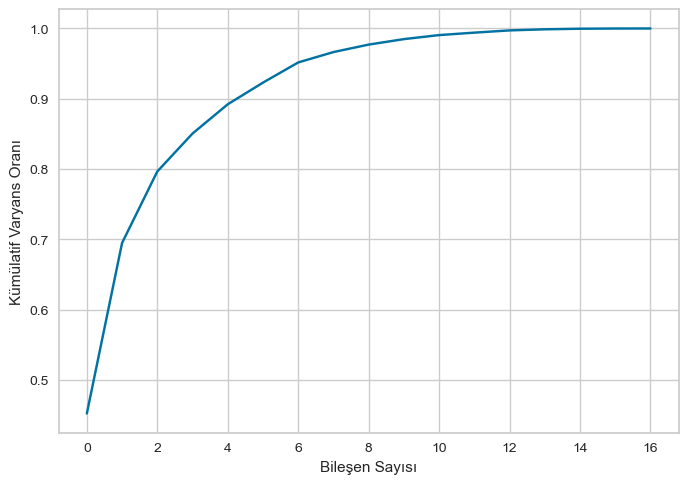

In [78]:
pca = PCA().fit(df)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Bileşen Sayısı")
plt.ylabel("Kümülatif Varyans Oranı");

In [79]:
pca.explained_variance_ratio_

array([4.52454661e-01, 2.42468012e-01, 1.01696801e-01, 5.39343967e-02,
       4.16143455e-02, 3.08119274e-02, 2.86933912e-02, 1.47589096e-02,
       1.06379741e-02, 7.78968542e-03, 5.72654636e-03, 3.49183444e-03,
       3.16734133e-03, 1.57268674e-03, 8.27965421e-04, 2.82821576e-04,
       7.06999352e-05])

#### final modeli


In [80]:
## Grafiğe bakarsak alt değerlere +1 ekle :D, 3 değişkenle veri setinin %80 ini açıklayabiliyoruz..

In [81]:
pca = PCA(n_components=3)
pca_fit = pca.fit_transform(df)

In [82]:
pca.explained_variance_ratio_

array([0.45245466, 0.24246801, 0.1016968 ])